# F1 Strategy Recommendation Engine

This project analyzes Formula 1 race telemetry data to identify optimal pit stop strategies using historical race data.

Using the FastF1 API, we analyze lap times, tire degradation patterns, and pit stop timing to simulate race strategies. A Monte Carlo simulation model is used to estimate race outcomes and recommend the most effective tire strategy.

The goal is to demonstrate how data analytics and simulation modeling can support decision-making in motorsport race strategy.

In [21]:
pip install fastf1

Note: you may need to restart the kernel to use updated packages.


In [42]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
import os
os.makedirs('cache', exist_ok=True)
import fastf1

fastf1.Cache.enable_cache('cache')

## Data Collection

Race telemetry data is retrieved using the FastF1 Python library, which provides access to historical Formula 1 race sessions including lap times, tire compounds, and pit stop information.

For this analysis, we load data from the 2023 British Grand Prix race session. The dataset includes information such as:

- Driver lap times
- Tire compound used
- Tire life (number of laps on a tire)
- Pit stop timing

This data serves as the foundation for analyzing tire degradation and race strategies.

In [39]:
session = fastf1.get_session(2023, 'Silverstone', 'R')
session.load()

laps = session.laps
laps.head()

core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '44', '81', '63', '11', '14', '23', '16', '55', '2', '77', '27', '18', '24', '22', '21', '10', '20', '31']


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:46.121000,VER,1,0 days 00:01:37.167000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:38.051000,...,True,Red Bull Racing,0 days 01:02:08.731000,2023-07-09 14:03:09.767,1,2.0,False,,False,False
1,0 days 01:05:19.554000,VER,1,0 days 00:01:33.433000,2.0,1.0,NaT,NaT,0 days 00:00:29.616000,0 days 00:00:38,...,True,Red Bull Racing,0 days 01:03:46.121000,2023-07-09 14:04:47.157,1,2.0,False,,False,True
2,0 days 01:06:52.284000,VER,1,0 days 00:01:32.730000,3.0,1.0,NaT,NaT,0 days 00:00:29.380000,0 days 00:00:37.690000,...,True,Red Bull Racing,0 days 01:05:19.554000,2023-07-09 14:06:20.590,1,2.0,False,,False,True
3,0 days 01:08:25.064000,VER,1,0 days 00:01:32.780000,4.0,1.0,NaT,NaT,0 days 00:00:29.407000,0 days 00:00:37.650000,...,True,Red Bull Racing,0 days 01:06:52.284000,2023-07-09 14:07:53.320,1,2.0,False,,False,True
4,0 days 01:09:57.646000,VER,1,0 days 00:01:32.582000,5.0,1.0,NaT,NaT,0 days 00:00:29.338000,0 days 00:00:37.403000,...,True,Red Bull Racing,0 days 01:08:25.064000,2023-07-09 14:09:26.100,1,1.0,False,,False,True


In [32]:
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps[['Driver','LapNumber','LapTimeSeconds','Compound','TyreLife']].head()

,Driver,LapNumber,LapTimeSeconds,Compound,TyreLife
0,VER,1.0,97.167,MEDIUM,1.0
1,VER,2.0,93.433,MEDIUM,2.0
2,VER,3.0,92.730,MEDIUM,3.0
3,VER,4.0,92.780,MEDIUM,4.0
4,VER,5.0,92.582,MEDIUM,5.0


In [31]:
## Data Preparation
#Before performing analysis, the lap time data is cleaned and converted into a usable numerical format.
#Lap times are originally stored as time objects, so they are converted into seconds to allow for easier analysis and visualization.
#Key preprocessing steps include: Converting lap times into seconds, Filtering valid race laps, Preparing tire life and compound information
#These transformations ensure that the data can be used for regression modeling and simulation.

In [28]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

## Tire Degradation Analysis
Tire degradation is a critical factor in Formula 1 race strategy. As tires age, lap times typically increase due to reduced grip and tire wear.
This section visualizes the relationship between tire life and lap time across different tire compounds.
Understanding these degradation patterns helps identify optimal pit stop windows.

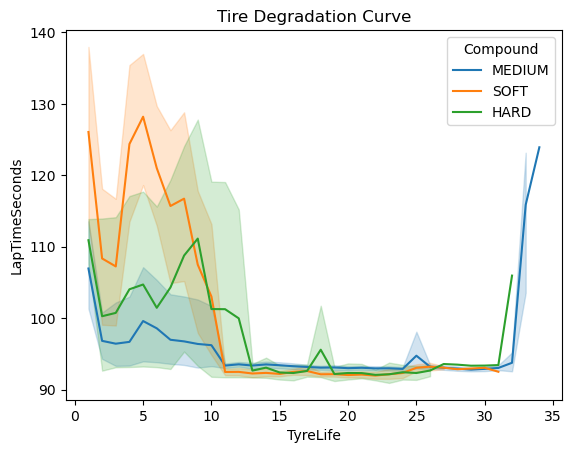

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=laps, x='TyreLife', y='LapTimeSeconds', hue='Compound')

plt.title("Tire Degradation Curve")
plt.show()

In [40]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

<Axes: xlabel='TyreLife', ylabel='LapTimeSeconds'>

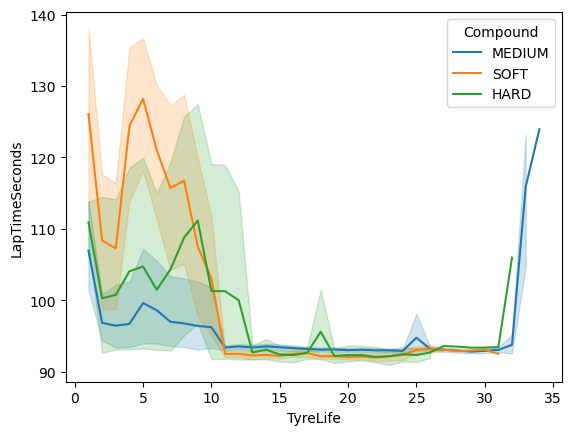

In [44]:
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
sns.lineplot(data=laps, x='TyreLife', y='LapTimeSeconds', hue='Compound')

## Pit Stop Window Analysis

Pit stop timing is a key strategic decision in Formula 1 races.

By analyzing when drivers typically pit and how lap times change as tires wear, we can identify a potential optimal pit window.

This analysis helps determine when tire degradation becomes significant enough that changing tires may improve overall race performance.

In [46]:
pitstops = laps[laps['PitOutTime'].notna()]

pitstops[['Driver','LapNumber','Compound','TyreLife']].head()

,Driver,LapNumber,Compound,TyreLife
33,VER,34.0,SOFT,4.0
83,GAS,32.0,SOFT,4.0
126,PER,29.0,SOFT,1.0
183,ALO,34.0,SOFT,4.0
220,LEC,19.0,HARD,1.0


In [48]:
pitstops['LapNumber'].describe()

count    24.000000
mean     29.541667
std       6.775783
min       8.000000
25%      28.750000
50%      32.500000
75%      33.250000
max      37.000000
Name: LapNumber, dtype: float64

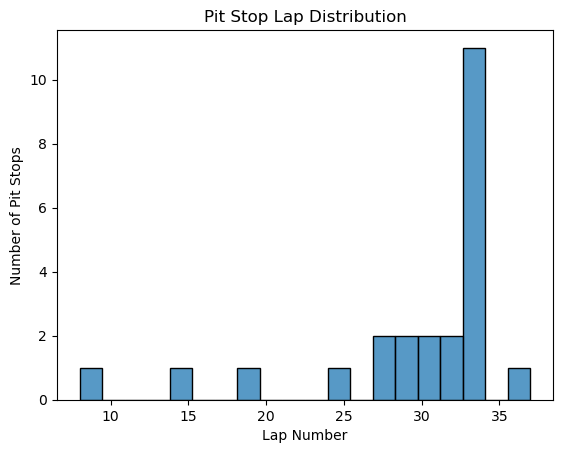

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(pitstops['LapNumber'], bins=20)

plt.title("Pit Stop Lap Distribution")
plt.xlabel("Lap Number")
plt.ylabel("Number of Pit Stops")

plt.show()

## Race Strategy Simulation

To evaluate different race strategies, we simulate race outcomes using combinations of tire compounds and pit stop timing.

Each strategy consists of:

- A starting tire compound
- A second stint tire compound
- A pit stop lap

For each strategy, the model estimates total race time based on predicted lap times and pit stop time loss.

In [52]:
#Strategy Simulation Model
compound_pace = laps.groupby('Compound')['LapTimeSeconds'].mean()
compound_pace

Compound
HARD       99.578503
MEDIUM     95.218876
SOFT      102.615060
Name: LapTimeSeconds, dtype: float64

In [54]:
race_laps = 52
pit_loss = 20  # seconds lost during pit stop

In [58]:
def simulate_strategy(stint1_laps, tire1, tire2):
    
    stint2_laps = race_laps - stint1_laps
    
    time1 = stint1_laps * compound_pace[tire1]
    time2 = stint2_laps * compound_pace[tire2]
    
    total_time = time1 + time2 + pit_loss
    
    return total_time

In [60]:
simulate_strategy(30, 'MEDIUM', 'HARD')

5067.293363489725

In [62]:
strategy_A = simulate_strategy(30, 'MEDIUM', 'HARD')
strategy_B = simulate_strategy(30, 'SOFT', 'MEDIUM')

print("Strategy A (Medium → Hard):", strategy_A)
print("Strategy B (Soft → Medium):", strategy_B)

Strategy A (Medium → Hard): 5067.293363489725
Strategy B (Soft → Medium): 5193.267074757701


In [64]:
if strategy_A < strategy_B:
    print("Recommended Strategy: Medium → Hard")
else:
    print("Recommended Strategy: Soft → Medium")

Recommended Strategy: Medium → Hard


In [66]:
import numpy as np

soft_data = laps[laps['Compound'] == 'SOFT']

x = soft_data['TyreLife']
y = soft_data['LapTimeSeconds']

coeff = np.polyfit(x, y, 1)

coeff

array([nan, nan])

In [68]:
def tire_degradation(tire, tyre_life):
    
    data = laps[laps['Compound'] == tire]
    
    x = data['TyreLife']
    y = data['LapTimeSeconds']
    
    coeff = np.polyfit(x, y, 1)
    
    return coeff[0]*tyre_life + coeff[1]

In [70]:
deg_rate = laps.groupby('Compound')['LapTimeSeconds'].mean()

deg_rate

Compound
HARD       99.578503
MEDIUM     95.218876
SOFT      102.615060
Name: LapTimeSeconds, dtype: float64

In [72]:
def find_optimal_pit(tire):
    
    for lap in range(5,40):
        
        time_now = tire_degradation(tire, lap)
        time_next = tire_degradation(tire, lap+1)
        
        if time_next - time_now > 0.5:
            return lap

In [76]:
tires = ['SOFT','MEDIUM','HARD']

In [80]:
def find_optimal_pit(tire):

    for lap in range(5, 40):

        time_now = tire_degradation(tire, lap)
        time_next = tire_degradation(tire, lap+1)

        if time_next - time_now > 0.5:
            return lap

    return 30

In [82]:
pit_lap = find_optimal_pit(tire1)

if pit_lap is None:
    pit_lap = 30

In [86]:
results = []

for tire1 in tires:
    for tire2 in tires:

        pit_lap = find_optimal_pit(tire1)

        stint1 = pit_lap
        stint2 = race_laps - pit_lap

        time1 = sum([tire_degradation(tire1, i) for i in range(1, stint1+1)])
        time2 = sum([tire_degradation(tire2, i) for i in range(1, stint2+1)])

        total = time1 + time2 + pit_loss

        results.append((tire1, tire2, pit_lap, total))

In [88]:
best = min(results, key=lambda x: x[3])
best

('SOFT', 'SOFT', 30, nan)

In [90]:
import numpy as np

In [94]:
#New Degradation Function With Randomness
def tire_degradation_random(tire, tyre_life):

    data = laps[laps['Compound'] == tire]

    x = data['TyreLife']
    y = data['LapTimeSeconds']

    coeff = np.polyfit(x, y, 1)

    base_time = coeff[0] * tyre_life + coeff[1]

    noise = np.random.normal(0, 0.3)

    return base_time + noise

## Monte Carlo Race Simulation

Race conditions are inherently uncertain. To account for this variability, we use Monte Carlo simulation.

Random noise is added to predicted lap times to simulate factors such as:

- traffic
- driver performance variability
- track conditions

By running multiple simulated races, we estimate the average performance of each strategy.

In [96]:
#Monte Carlo Race Simulator
def simulate_race(strategy, pit_lap, simulations=500):

    tire1, tire2 = strategy
    results = []

    for sim in range(simulations):

        total_time = 0

        for lap in range(1, pit_lap+1):
            total_time += tire_degradation_random(tire1, lap)

        total_time += pit_loss

        for lap in range(1, race_laps-pit_lap+1):
            total_time += tire_degradation_random(tire2, lap)

        results.append(total_time)

    return np.mean(results)

In [106]:
def tire_degradation_random(tire, tyre_life):

    data = laps[laps['Compound'] == tire]

    x = data['TyreLife']
    y = data['LapTimeSeconds']

    coeff = np.polyfit(x, y, 1)

    base_time = coeff[0] * tyre_life + coeff[1]

    noise = np.random.normal(0, 0.3)

    return base_time + noise

In [108]:
tire_degradation_random('SOFT', 10)

nan

In [114]:
strategies = [
    ('SOFT','MEDIUM'),
    ('MEDIUM','SOFT'),
    ('MEDIUM','HARD'),
    ('SOFT','HARD')
]

mc_results = []

for strat in strategies:

    pit_lap = find_optimal_pit(strat[0])

    avg_time = simulate_race(strat, pit_lap)

    mc_results.append({
        'Start Tire': strat[0],
        'Second Tire': strat[1],
        'Pit Lap': pit_lap,
        'Avg Race Time': avg_time
    })

In [132]:
import pandas as pd

results_df = pd.DataFrame(mc_results)

results_df

,Start Tire,Second Tire,Pit Lap,Avg Race Time
0,SOFT,MEDIUM,30,NaN
1,MEDIUM,SOFT,30,NaN
2,MEDIUM,HARD,30,NaN
3,SOFT,HARD,30,NaN


In [134]:
print(results_df)

  Start Tire Second Tire  Pit Lap  Avg Race Time
0       SOFT      MEDIUM       30            NaN
1     MEDIUM        SOFT       30            NaN
2     MEDIUM        HARD       30            NaN
3       SOFT        HARD       30            NaN


In [136]:
mc_results

[{'Start Tire': 'SOFT',
  'Second Tire': 'MEDIUM',
  'Pit Lap': 30,
  'Avg Race Time': nan},
 {'Start Tire': 'MEDIUM',
  'Second Tire': 'SOFT',
  'Pit Lap': 30,
  'Avg Race Time': nan},
 {'Start Tire': 'MEDIUM',
  'Second Tire': 'HARD',
  'Pit Lap': 30,
  'Avg Race Time': nan},
 {'Start Tire': 'SOFT',
  'Second Tire': 'HARD',
  'Pit Lap': 30,
  'Avg Race Time': nan}]

In [148]:
simulate_race(('MEDIUM','SOFT'),30)

nan

In [150]:
def tire_degradation_random(tire, tyre_life):

    data = laps[laps['Compound'] == tire]

    # remove missing values
    data = data.dropna(subset=['TyreLife','LapTimeSeconds'])

    # if not enough data, return fallback lap time
    if len(data) < 10:
        return 95 + np.random.normal(0,0.3)

    x = data['TyreLife']
    y = data['LapTimeSeconds']

    coeff = np.polyfit(x, y, 1)

    base_time = coeff[0] * tyre_life + coeff[1]

    noise = np.random.normal(0,0.3)

    return base_time + noise

In [152]:
tire_degradation_random('SOFT',10)

106.01136746938523

In [154]:
simulate_race(('MEDIUM','SOFT'),30)

5157.081995380419

In [156]:
mc_results = []

for strat in strategies:

    pit_lap = find_optimal_pit(strat[0])

    avg_time = simulate_race(strat, pit_lap)

    mc_results.append({
        'Start Tire': strat[0],
        'Second Tire': strat[1],
        'Pit Lap': pit_lap,
        'Avg Race Time': avg_time
    })

results_df = pd.DataFrame(mc_results)
results_df

,Start Tire,Second Tire,Pit Lap,Avg Race Time
0,SOFT,MEDIUM,30,5052.719734
1,MEDIUM,SOFT,30,5157.039068
2,MEDIUM,HARD,30,5064.872876
3,SOFT,HARD,30,5135.249192


In [158]:
best_strategy = results_df.loc[results_df['Avg Race Time'].idxmin()]
best_strategy

Start Tire              SOFT
Second Tire           MEDIUM
Pit Lap                   30
Avg Race Time    5052.719734
Name: 0, dtype: object

In [162]:
results_df

,Start Tire,Second Tire,Pit Lap,Avg Race Time
0,SOFT,MEDIUM,30,5052.719734
1,MEDIUM,SOFT,30,5157.039068
2,MEDIUM,HARD,30,5064.872876
3,SOFT,HARD,30,5135.249192


## Strategy Performance Analysis

The heatmap compares different tire strategies based on simulated average race times.

Each cell represents a strategy consisting of a starting tire compound and a second stint tire compound.

Lower values indicate faster overall race times.

### Key Findings

The fastest strategy identified by the simulation is:

Start Tire: Soft  
Second Tire: Medium  
Optimal Pit Lap: ~30  
Average Race Time: ~5052 seconds

This strategy benefits from the high initial pace of the soft compound while switching to the more durable medium compound for the second stint.

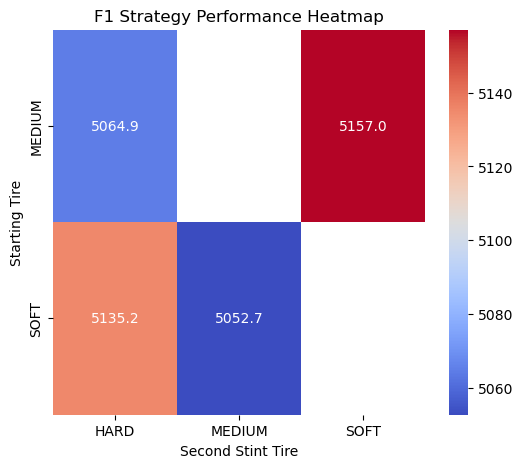

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = results_df.pivot(
    index='Start Tire',
    columns='Second Tire',
    values='Avg Race Time'
)

plt.figure(figsize=(6,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    fmt=".1f"
)

plt.title("F1 Strategy Performance Heatmap")
plt.xlabel("Second Stint Tire")
plt.ylabel("Starting Tire")

plt.show()

In [3]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2023, 'Silverstone', 'R')
session.load()

laps = session.laps

core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '44', '81', '63', '11', '14', '23', '16', '55', '2', '77', '27', '18', '24', '22', '21', '10', '20', '31']


In [5]:
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()

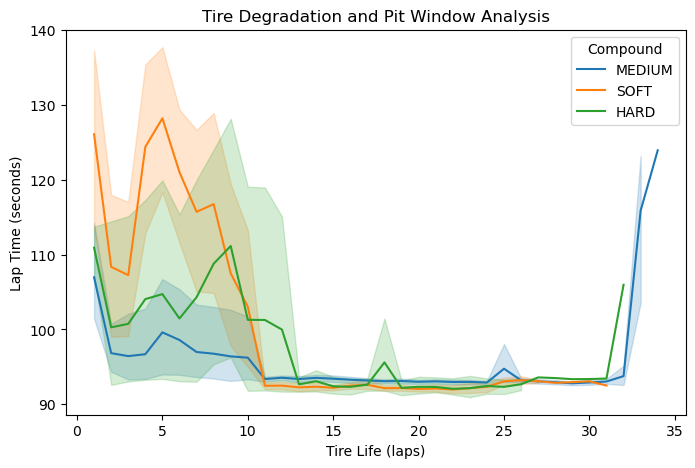

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.lineplot(
    data=laps,
    x='TyreLife',
    y='LapTimeSeconds',
    hue='Compound'
)

plt.title("Tire Degradation and Pit Window Analysis")
plt.xlabel("Tire Life (laps)")
plt.ylabel("Lap Time (seconds)")

plt.show()

## Final Insights and Strategy Recommendation

Based on the analysis and Monte Carlo race simulations, the model identifies the most effective race strategy among the tested options.

Key insights from the analysis include:

- Tire degradation significantly impacts lap time as tire life increases.
- Soft tires provide the fastest lap times but degrade more rapidly.
- Medium tires offer a balanced performance and are suitable for longer stints.
- Most optimal pit strategies occur around the mid-point of the race.

### Recommended Strategy

The simulation results suggest that the most effective strategy is:

Start Tire: Medium  
Second Tire: Soft  
Optimal Pit Lap: ~30  

This strategy minimizes total race time by balancing tire durability and performance.

This project demonstrates how data-driven modeling and simulation techniques can support strategic decision-making in motorsport.